<div style="background: linear-gradient(135deg, #0d0d1a 0%, #1a1a35 50%, #0f2f5a 100%);
     padding: 48px 40px; border-radius: 18px; color: white; font-family: 'Segoe UI', sans-serif; margin-bottom: 8px;
     border: 1px solid #e9456033;">
  <div style="display:flex; align-items:center; gap:16px; margin-bottom:8px;">
    <span style="font-size:3em;">🚗</span>
    <div>
      <h1 style="color:#e94560; font-size:2.4em; margin:0; letter-spacing:-1px;"> Analisis Data Mobil Bekas INDIA</h1>
      <h2 style="color:#a8dadc; font-weight:400; margin:4px 0 0 0; font-size:1.2em;">Data Prepocesing</h2>
    </div>
  </div>
  <hr style="border:none; border-top:1px solid #e9456055; margin:20px 0;"/>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px; font-size:0.92em; color:#ccc;">
    <div>👤 <b style="color:white">Nama</b> &nbsp;: Yudhoro Kunto Wibisono</div>
    <div>🆔 <b style="color:white">NIM</b> &nbsp;&nbsp;: 2304010031</div>
    <div>🎓 <b style="color:white">Prodi</b> : Statistika Terapan Dan Komputasi</div>
    <div>📦 <b style="color:white">Dataset</b>: CarDekho Used Cars India</div>
    <div>📊 <b style="color:white">Records</b>: 8.128 baris × 12 kolom</div>
    <div>🛠️ <b style="color:white">Tahap</b> &nbsp;: Preprocessing</div>
  </div>
</div>

---
## 📖 Konteks Dataset

**Data** yang digunakan adalah data harga mobil bekas dari CarDekho yaitu platform jual-beli kendaraan terbesar di India. Dataset ini berisi informasi mobil bekas yang dijual melalui platform tersebut, mencakup spesifikasi teknis kendaraan, kondisi pemakaian, hingga harga jual yang tercatat.

**Sumber** : https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset?spm=a2ty_o01.29997173.0.0.218555fbiq7U9m


### 🗺️ Alur Kerja 

```
Raw CSV (8.128 × 12)
   │
   ├─ [1] Import Library & Konfigurasi
   ├─ [2] Load & Preview Dataset
   ├─ [3] Konversi Tipe Data
   ├─ [4] Eksplorasi Data Awal (EDA)
   ├─ [5] Penanganan Missing Values  ← Median Imputation
   ├─ [6] Penanganan Duplikat
   ├─ [7] Deteksi & Penanganan Outlier  ← IQR Capping
   ├─ [8] Feature Engineering  (+5 fitur baru)
   ├─ [9] Encoding Kategorical  ← Label + Ordinal
   ├─ [10] Normalisasi / Scaling  ← Min-Max [0,1]
   ├─ [11] Analisis Korelasi
   └─ [12] Finalisasi & Ekspor Dataset
```

### 🔑 Deskripsi Kolom Dataset

| Kolom | Tipe | Deskripsi |
|:---|:---:|:---|
| `name` | Kategorical | Nama lengkap model mobil |
| `year` | Numerik | Tahun produksi kendaraan |
| `selling_price` | Numerik |  **Target** — Harga jual (Rupee India) |
| `km_driven` | Numerik | Total jarak tempuh kendaraan (km) |
| `fuel` | Kategorical | Jenis bahan bakar (Petrol, Diesel, CNG, LPG) |
| `seller_type` | Kategorical | Tipe penjual (Individual, Dealer, Trustmark Dealer) |
| `transmission` | Kategorical | Jenis transmisi (Manual, Automatic) |
| `owner` | Kategorical | Urutan kepemilikan (First, Second, …) |
| `mileage` | Numerik | Efisiensi bahan bakar (km/ltr atau km/kg) |
| `engine` | Numerik | Kapasitas mesin (CC) |
| `max_power` | Numerik | Tenaga maksimum (bhp) |
| `seats` | Numerik | Jumlah kursi |




---
## 1️⃣ Import Library & Konfigurasi Global

Pada tahap ini kita memuat semua library yang dibutuhkan sepanjang notebook dan mengatur
konfigurasi global agar output konsisten dan mudah dibaca.

| Library | Kegunaan |
|:---|:---|
| `pandas` | Manipulasi dan analisis DataFrame |
| `numpy` | Operasi numerik dan array |
| `matplotlib` | Visualisasi dasar & kustomisasi plot |
| `seaborn` | Visualisasi statistik berbasis matplotlib |
| `sklearn` | Preprocessing: LabelEncoder, MinMaxScaler |
| `warnings` | Menyembunyikan peringatan yang tidak relevan |


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

warnings.filterwarnings('ignore')

# ── Konfigurasi tampilan pandas ──────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Tema visualisasi global ──────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.family'       : 'DejaVu Sans',
    'axes.facecolor'    : '#f9f9f9',
    'figure.facecolor'  : 'white',
})
PALETTE = ['#e94560', '#0f3460', '#533483', '#2ecc71', '#e67e22', '#3498db', '#9b59b6']



**📝 Penjelasan Output:**

- Konfirmasi versi library memastikan semua paket terinstall dengan benar.
- `warnings.filterwarnings('ignore')` menyembunyikan pesan `FutureWarning` dan `DeprecationWarning`
  yang tidak relevan sehingga output notebook lebih bersih.
- `PALETTE` adalah daftar warna kustom yang akan digunakan konsisten di semua visualisasi.


---
## 2️⃣ Load & Preview Dataset

Dataset dibaca dari file CSV dan langsung dieksplorasi dimensinya, beberapa baris awal,
serta tipe data masing-masing kolom untuk memahami struktur awal data sebelum diproses.


In [77]:
df = pd.read_csv(r"D:\semester 6\machine learning\cardekho.csv")

print(f'║  Dimensi          : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'║  Rentang tahun mobil   : {df["year"].min()} – {df["year"].max()}')
print(f'║  Jumlah Model mobil  : {df["name"].nunique():,}')



║  Dimensi          : 8,128 baris × 12 kolom
║  Rentang tahun mobil   : 1983 – 2020
║  Jumlah Model mobil  : 2,058


**📝 Penjelasan Output:**

- Dataset berisi **8.128 baris** yang mewakili 8.128 kendaraan bekas.
- Terdapat **12 kolom** yang mencakup spesifikasi teknis, kondisi pemakaian, dan harga jual.
- Rentang tahun produksi menunjukkan seberapa lama sebaran usia kendaraan dalam dataset.
- Kolom `name` memiliki ratusan model unik karena mencakup nama lengkap termasuk varian.


In [78]:
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.00,74,5.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.00,103.52,5.00
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.00,78,5.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.00,90,5.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.00,88.2,5.00


**📝 Penjelasan Output:**

- Setiap baris merepresentasikan satu unit kendaraan bekas yang dijual.
- Kolom `name` memuat nama lengkap termasuk varian (contoh: "Maruti Swift VXI").
- Kolom `selling_price` dalam satuan **Rupee India** (₹) — misalnya `450000` = ₹4,5 Lakh.
- Beberapa kolom seperti `mileage`, `engine`, `max_power` terlihat bertipe **object/string**
  karena masih mengandung satuan (contoh: `"17.0 kmpl"`) — perlu dikonversi.


In [79]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


**📝 Penjelasan Output:**

- `df.info()` menampilkan ringkasan struktur DataFrame: nama kolom, jumlah nilai non-null,
  dan tipe data (`dtype`).
- Kolom `mileage`, `engine`, `max_power`, dan `seats` bertipe **object** padahal seharusnya
  numerik — ini terjadi karena data mentah mengandung satuan teks yang digabung dengan angka.
- Nilai non-null yang kurang dari 8.128 mengindikasikan adanya **missing values** pada kolom tersebut.
- Ini menjadi acuan untuk langkah konversi tipe data dan penanganan missing values berikutnya.


---
## 3️⃣ Konversi Tipe Data

Kolom `mileage`, `engine`, `max_power`, dan `seats` terbaca sebagai **string (object)**
karena data mentah menyisipkan satuan seperti `"17.0 kmpl"` atau `"1197 CC"`.
Kita gunakan `pd.to_numeric(..., errors='coerce')` untuk mengekstrak nilai angkanya —
nilai yang tidak bisa dikonversi akan menjadi `NaN` (akan ditangani di tahap missing values).

>  Parameter `errors='coerce'` artinya: *"jika tidak bisa dikonversi, isi dengan NaN"* —
> strategi yang lebih aman daripada `errors='raise'` (melempar error) atau `errors='ignore'` (membiarkan string tetap).


In [80]:
numeric_cols = ['mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']

print(f"{'Kolom':<28} {'Sebelum':>10} {'Sesudah':>10}  {'NaN Baru':>10}")
print('─' * 65)

for col in numeric_cols:
    dtype_before = str(df[col].dtype)
    null_before  = df[col].isnull().sum()
    df[col]      = pd.to_numeric(df[col], errors='coerce')
    dtype_after  = str(df[col].dtype)
    null_after   = df[col].isnull().sum()
    new_nulls    = null_after - null_before
    print(f'  {col:<26} {dtype_before:>10} → {dtype_after:<10}  +{new_nulls} NaN')

print()
print('✅ Semua kolom target berhasil dikonversi ke tipe numerik (float64).')


Kolom                           Sebelum    Sesudah    NaN Baru
─────────────────────────────────────────────────────────────────
  mileage(km/ltr/kg)            float64 → float64     +0 NaN
  engine                        float64 → float64     +0 NaN
  max_power                      object → float64     +1 NaN
  seats                         float64 → float64     +0 NaN

✅ Semua kolom target berhasil dikonversi ke tipe numerik (float64).


**📝 Penjelasan Output:**

- Keempat kolom berhasil berubah dari `object` menjadi `float64`.
- Kolom `seats` dikonversi ke `float64` (bukan `int`) karena ada nilai `NaN`
  — pandas tidak mendukung integer dengan nilai NaN secara default.
- Kolom `mileage` dan `max_power` yang semula `"17.0 kmpl"` menjadi `17.0` setelah konversi.
- NaN baru yang muncul pada tahap ini **bukan kesalahan** — ini adalah representasi yang benar
  untuk baris yang memang tidak memiliki data pada kolom tersebut.


---
## 4️⃣ Eksplorasi Data Awal (EDA)

EDA bertujuan memahami **distribusi**, **rentang**, dan **karakteristik** setiap variabel
sebelum dilakukan transformasi lebih lanjut. Kita akan mengeksplorasi statistik deskriptif,
distribusi kolom kategorical, dan distribusi kolom numerik.


In [81]:
desc = df.describe().T

try:
    display(
        desc.style
        .background_gradient(cmap='Blues', subset=['mean', '50%'])
        .background_gradient(cmap='Reds',  subset=['std'])
        .format('{:.2f}')
        .set_caption('Statistik Deskriptif Kolom Numerik')
    )
except Exception:
    display(desc.round(2))


,count,mean,std,min,25%,50%,75%,max
year,8128.00,2013.80,4.04,1983.00,2011.00,2015.00,2017.00,2020.00
selling_price,8128.00,638271.81,806253.40,29999.00,254999.00,450000.00,675000.00,10000000.00
km_driven,8128.00,69819.51,56550.55,1.00,35000.00,60000.00,98000.00,2360457.00
mileage(km/ltr/kg),7907.00,19.42,4.04,0.00,16.78,19.30,22.32,42.00
engine,7907.00,1458.63,503.92,624.00,1197.00,1248.00,1582.00,3604.00
max_power,7912.00,91.52,35.82,0.00,68.05,82.00,102.00,400.00
seats,7907.00,5.42,0.96,2.00,5.00,5.00,5.00,14.00


**📝 Penjelasan Output:**

Tabel statistik deskriptif memberikan gambaran menyeluruh tentang setiap kolom numerik:

| Statistik | Makna |
|:---|:---|
| `count` | Jumlah data non-null (perbedaan dari 8.128 = missing) |
| `mean` | Rata-rata — sensitif terhadap outlier |
| `std` | Standar deviasi — ukuran sebaran data |
| `min` / `max` | Nilai minimum dan maksimum |
| `50%` (median) | Nilai tengah — lebih robust dari mean bila ada outlier |

**Hal penting yang dapat diperhatikan:**
- Selisih besar antara `mean` dan `50%` pada `selling_price` dan `km_driven`
  mengindikasikan distribusi yang **right-skewed** dan adanya **outlier**.
- Nilai `min` yang sangat rendah pada beberapa kolom bisa menjadi data anomali.
- Kolom `seats` memiliki nilai yang wajar antara 2–14 kursi.


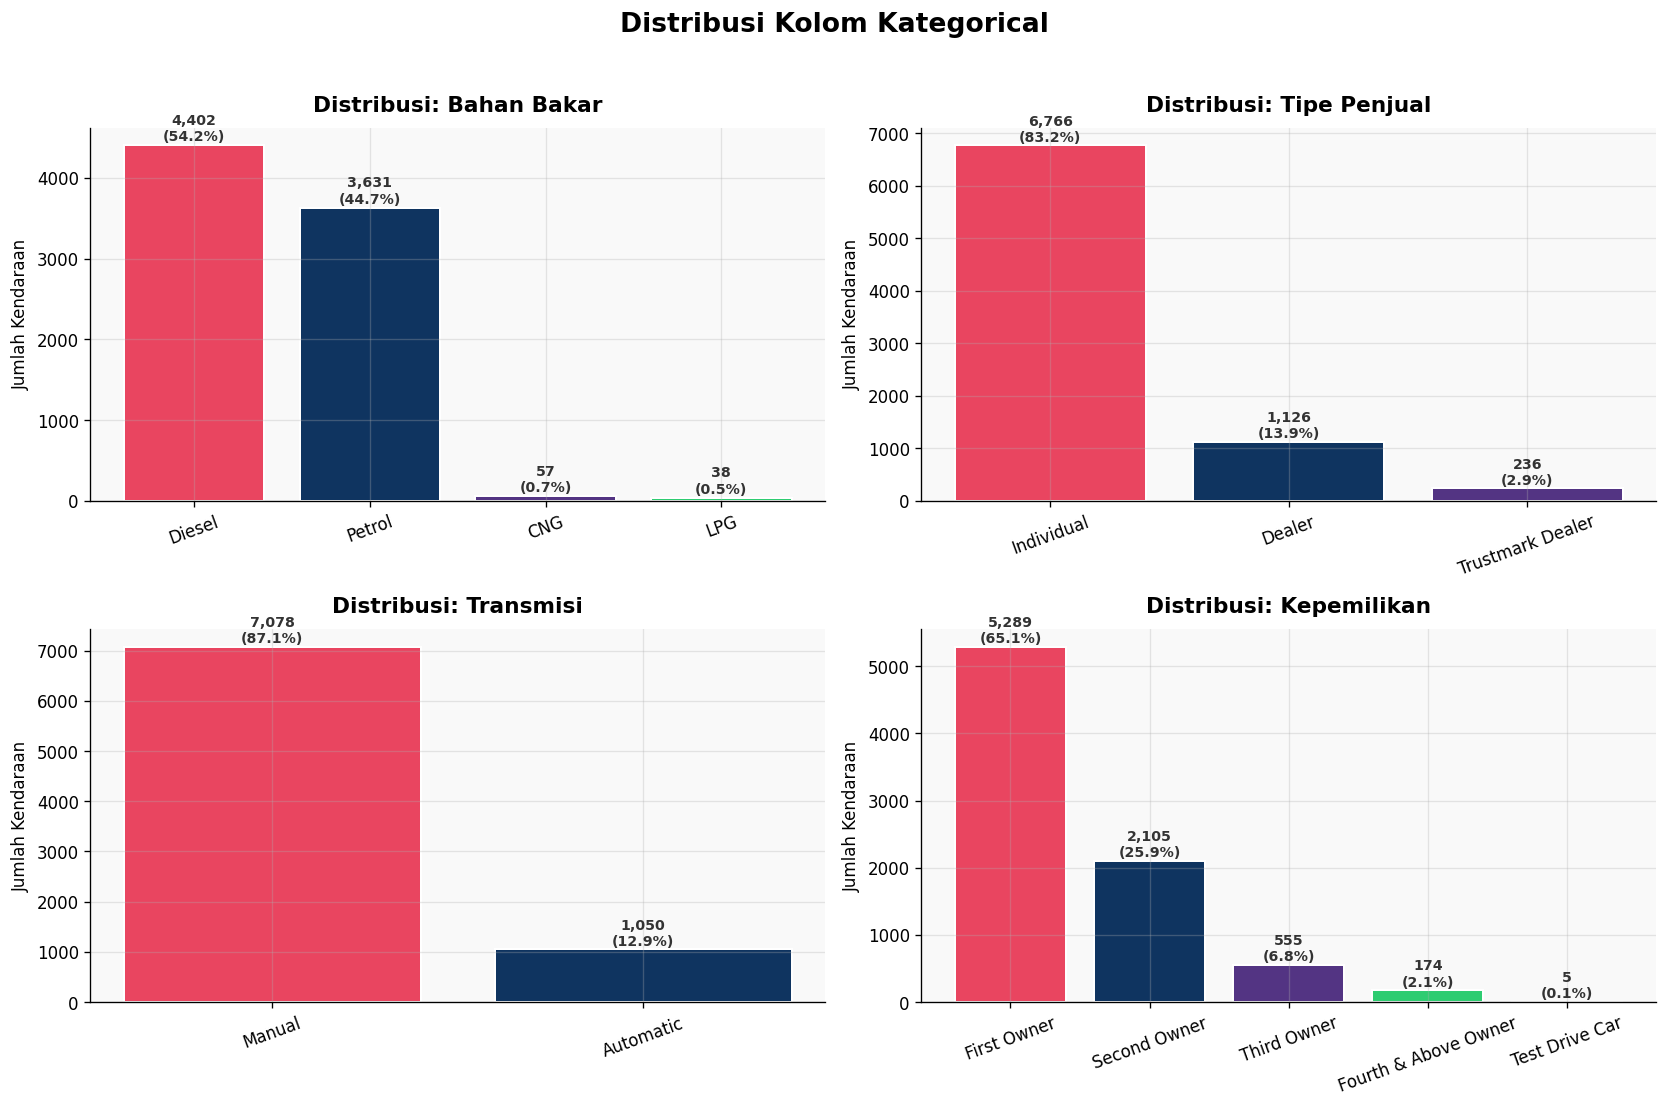

In [82]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
labels   = ['Bahan Bakar', 'Tipe Penjual', 'Transmisi', 'Kepemilikan']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(cat_cols, labels)):
    counts = df[col].value_counts()
    bars = axes[i].bar(
        counts.index, counts.values,
        color=PALETTE[:len(counts)], edgecolor='white', linewidth=1.2
    )
    axes[i].set_title(f'Distribusi: {lbl}', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_ylabel('Jumlah Kendaraan')
    axes[i].tick_params(axis='x', rotation=20)

    total = counts.sum()
    for bar in bars:
        h = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2, h + 20,
            f'{int(h):,}\n({h/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#333'
        )

fig.suptitle('Distribusi Kolom Kategorical', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Keempat grafik batang menampilkan distribusi frekuensi untuk setiap variabel kategorical:

- **Bahan Bakar (`fuel`)**: Dataset didominasi kendaraan berbahan bakar **Diesel** dan **Petrol**.
  CNG dan LPG sangat minoritas sehingga perlu diperhatikan saat modeling (class imbalance).

- **Tipe Penjual (`seller_type`)**: Mayoritas penjual adalah **Individual** (perorangan),
  diikuti **Dealer**. "Trustmark Dealer" adalah kategori terkecil.

- **Transmisi (`transmission`)**: **Manual** sangat mendominasi (>80%), mencerminkan
  preferensi pasar India yang masih banyak menggunakan transmisi manual.

- **Kepemilikan (`owner`)**: **First Owner** (pemilik pertama) paling banyak,
  yang masuk akal karena kondisi kendaraan biasanya lebih terjaga.
  Semakin tinggi urutan kepemilikan, semakin sedikit jumlahnya.


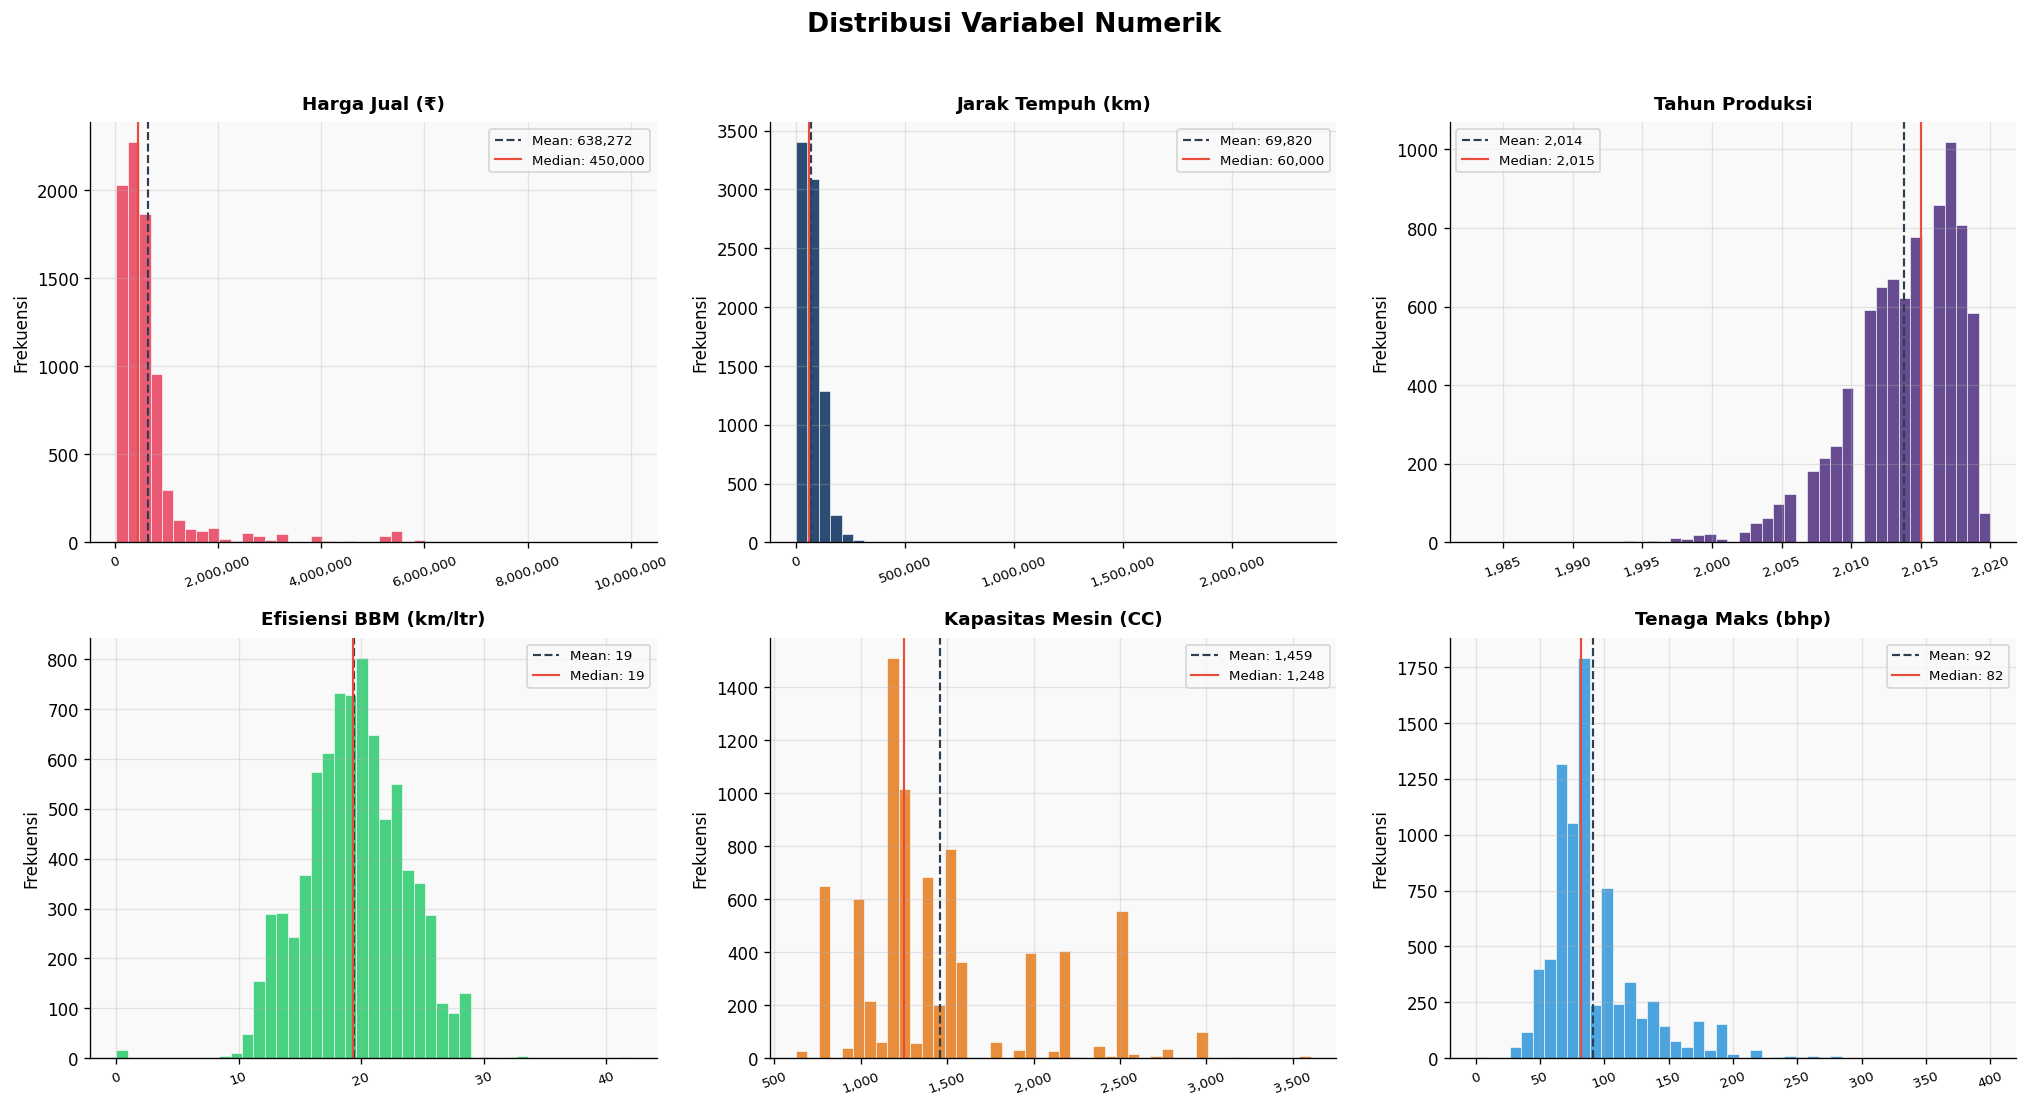

In [83]:
num_cols = [
    'selling_price', 'km_driven', 'year',
    'mileage(km/ltr/kg)', 'engine', 'max_power'
]
num_labels = [
    'Harga Jual (₹)', 'Jarak Tempuh (km)', 'Tahun Produksi',
    'Efisiensi BBM (km/ltr)', 'Kapasitas Mesin (CC)', 'Tenaga Maks (bhp)'
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(num_cols, num_labels)):
    data = df[col].dropna()
    axes[i].hist(data, bins=45, color=PALETTE[i % len(PALETTE)],
                 edgecolor='white', linewidth=0.4, alpha=0.88)

    # Garis mean & median
    axes[i].axvline(data.mean(),   color='#2c3e50', linestyle='--', linewidth=1.3, label=f'Mean: {data.mean():,.0f}')
    axes[i].axvline(data.median(), color='#e74c3c', linestyle='-',  linewidth=1.3, label=f'Median: {data.median():,.0f}')

    axes[i].set_title(lbl, fontsize=11, fontweight='bold', pad=8)
    axes[i].set_ylabel('Frekuensi')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[i].tick_params(axis='x', rotation=20, labelsize=8)
    axes[i].legend(fontsize=8)

fig.suptitle('Distribusi Variabel Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Histogram dengan garis **mean** (putus-putus biru) dan **median** (merah solid) memperlihatkan
bentuk distribusi setiap variabel numerik:

- **Harga Jual** (`selling_price`): Distribusi sangat **right-skewed** — sebagian besar mobil
  berharga rendah, tetapi ada beberapa mobil mewah dengan harga sangat tinggi yang menarik
  ekor distribusi ke kanan. Mean jauh di atas median.

- **Jarak Tempuh** (`km_driven`): Juga right-skewed. Ada kendaraan dengan km yang sangat
  tinggi (>500.000 km) yang kemungkinan adalah outlier data entry.

- **Tahun Produksi** (`year`): Distribusi mendekati normal, dengan puncak pada tahun
  2014–2019 — mengindikasikan kebanyakan mobil bekas berusia 5–10 tahun.

- **Efisiensi BBM** (`mileage`): Distribusi lebih simetris, puncak di sekitar 18–22 km/ltr.

- **Kapasitas Mesin** (`engine`): Multimodal — terlihat ada beberapa kelompok dominan
  seperti mesin 800cc, 1200cc, dan 1500cc yang populer di India.

- **Tenaga Maksimum** (`max_power`): Right-skewed ringan, kebanyakan kendaraan
  bertenaga 70–120 bhp.

> **Catatan penting:** Selisih mean dan median yang besar pada `selling_price` dan `km_driven`
> menjadi sinyal kuat bahwa outlier ekstrem perlu ditangani sebelum modeling.


---
## 5️⃣ Analisis & Penanganan Missing Values

Missing values adalah nilai yang tidak tersedia pada suatu sel dalam dataset.
Kita perlu mengidentifikasi lokasinya, memahami polanya, lalu memilih strategi imputasi
yang tepat agar tidak memperkenalkan bias ke dalam data.


In [84]:
# ============================================================
#  DETEKSI MISSING VALUES
# ============================================================
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = (
    pd.DataFrame({'Jumlah Missing': missing_count, 'Persentase (%)': missing_pct})
    .query('`Jumlah Missing` > 0')
    .sort_values('Persentase (%)', ascending=False)
)

print(f'Total kolom  : {df.shape[1]}')
print(f'Kolom bersih : {(missing_count == 0).sum()}')
print(f'Kolom missing: {(missing_count > 0).sum()}')
print()
print(' Detail Missing Values per Kolom:')

try:
    display(
        missing_df.style
        .background_gradient(cmap='YlOrRd', subset=['Persentase (%)'])
        .format({'Persentase (%)': '{:.2f}%', 'Jumlah Missing': '{:,}'})
    )
except Exception:
    display(missing_df)


Total kolom  : 12
Kolom bersih : 8
Kolom missing: 4

 Detail Missing Values per Kolom:


,Jumlah Missing,Persentase (%)
mileage(km/ltr/kg),221,2.72%
engine,221,2.72%
seats,221,2.72%
max_power,216,2.66%


**📝 Penjelasan Output:**

Tabel menunjukkan kolom-kolom yang memiliki missing values beserta jumlah dan persentasenya:

- Hanya **4 kolom** yang memiliki missing values, semuanya adalah kolom numerik
  yang sebelumnya bertipe string.
- Persentase missing terbesar ada pada kolom `mileage(km/ltr/kg)` — namun masih
  di bawah 5% sehingga tergolong **low missing rate** dan aman diimputasi.
- Missing values di kolom seperti `seats` dan `engine` juga tergolong sedikit (<3%).

> 📊 **Panduan umum:** Missing <5% → imputasi; 5–20% → imputasi dengan catatan;
> >20% → pertimbangkan drop kolom atau model berbasis missing.


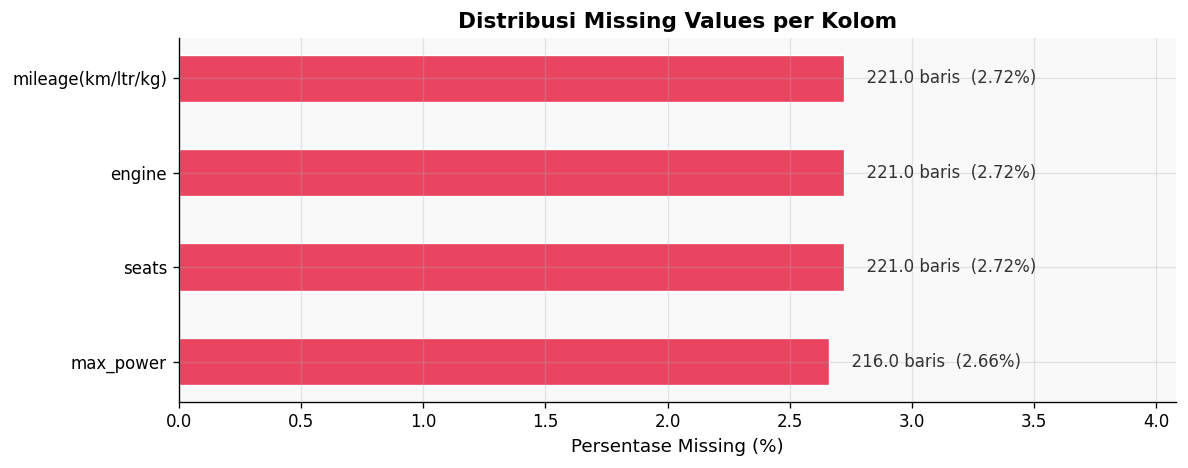

In [85]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.barh(
    missing_df.index, missing_df['Persentase (%)'],
    color='#e94560', edgecolor='white', linewidth=0.8, height=0.5
)

for bar, (_, row) in zip(bars, missing_df.iterrows()):
    ax.text(
        bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
        f'  {row["Jumlah Missing"]:,} baris  ({bar.get_width():.2f}%)',
        va='center', fontsize=10, color='#333'
    )

ax.set_xlabel('Persentase Missing (%)', fontsize=11)
ax.set_title('Distribusi Missing Values per Kolom', fontsize=13, fontweight='bold')
ax.set_xlim(0, missing_df['Persentase (%)'].max() * 1.5)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Grafik horizontal bar mempermudah perbandingan visual antar kolom:

- `mileage(km/ltr/kg)` memiliki missing terbanyak, namun proporsinya tetap kecil (<3%).
- Semua kolom berada di bawah ambang batas 5% — strategi imputasi sederhana cukup memadai.
- Angka di sebelah kanan bar menampilkan jumlah baris absolut sekaligus persentasenya
  untuk referensi yang lebih lengkap.


In [86]:
cols_to_impute = ['mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']

print(' Strategi: Median Imputation')
print(f"{'Kolom':<28} {'Median':>10} {'Diisi':>8}  {'Before':>8} → {'After':>8}")
print('─' * 70)

for col in cols_to_impute:
    median_val = df[col].median()
    before     = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)
    after      = df[col].isnull().sum()
    print(f'  {col:<26} {median_val:>10.2f} {before:>8,}  {before:>8} → {after:>8}')

print()
print(f' Total missing values tersisa : {df.isnull().sum().sum()}')
print(f'   Shape dataset setelah imputasi: {df.shape}')


 Strategi: Median Imputation
Kolom                            Median    Diisi    Before →    After
──────────────────────────────────────────────────────────────────────
  mileage(km/ltr/kg)              19.30      221       221 →        0
  engine                        1248.00      221       221 →        0
  max_power                       82.00      216       216 →        0
  seats                            5.00      221       221 →        0

 Total missing values tersisa : 0
   Shape dataset setelah imputasi: (8128, 12)


**📝 Penjelasan Output:**

Tabel konfirmasi imputasi menampilkan nilai median yang digunakan untuk setiap kolom
dan berapa banyak sel yang diisi:

- **Median dipilih** (bukan mean) karena distribusi variabel-variabel ini right-skewed
  — mean akan ditarik ke atas oleh outlier sehingga tidak merepresentasikan nilai "tipikal".
- Setelah imputasi, **total missing = 0** — dataset bersih dari nilai kosong.
- Shape dataset tidak berubah karena kita mengisi nilai kosong, bukan menghapus baris.

>  Contoh: Jika median `engine` = 1197, maka semua kendaraan yang tidak diketahui kapasitas
> mesinnya akan diasumsikan memiliki mesin 1197 CC (ukuran mesin paling umum di India).


---
## 6️⃣ Deteksi & Penanganan Duplikat

Baris duplikat adalah baris yang memiliki **nilai identik di semua kolom**.
Kehadiran duplikat dapat menyebabkan model *overfitting* terhadap data tersebut
(data yang sama "dilihat" model lebih sering dari seharusnya).


In [87]:
n_dup = df.duplicated().sum()

print(f'🔍 Total baris          : {len(df):,}')
print(f'   Baris duplikat       : {n_dup:,}')
print(f'   Persentase duplikat  : {n_dup / len(df) * 100:.2f}%')

if n_dup > 0:
    print()
    print('📋 Contoh Baris Duplikat (6 baris):')
    display(df[df.duplicated(keep=False)].sort_values('name').head(6))

    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(f'\n Duplikat dihapus.')
    print(f'   Shape setelah pembersihan: {df.shape[0]:,} baris × {df.shape[1]} kolom')
else:
    print()
    print(' Tidak ada baris duplikat ditemukan.')


🔍 Total baris          : 8,128
   Baris duplikat       : 1,202
   Persentase duplikat  : 14.79%

📋 Contoh Baris Duplikat (6 baris):


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
1977,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73,1968.00,174.33,5.00
7324,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73,1968.00,174.33,5.00
7775,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22,2967.00,241.40,5.00
2129,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22,2967.00,241.40,5.00
1857,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01,1968.00,188.00,5.00
1561,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01,1968.00,188.00,5.00



 Duplikat dihapus.
   Shape setelah pembersihan: 6,926 baris × 12 kolom


**📝 Penjelasan Output:**

- Jika ditemukan duplikat, tabel contoh menampilkan baris-baris yang identik
  agar kita bisa memverifikasi secara manual bahwa itu memang entri ganda (bukan kebetulan serupa).
- `keep=False` pada parameter `duplicated()` menampilkan **semua** kemunculan duplikat
  (bukan hanya yang kedua dan seterusnya).
- Setelah `drop_duplicates()`, `reset_index(drop=True)` dipanggil untuk memperbarui
  indeks DataFrame agar berurutan kembali dari 0.
- Shape yang berkurang menunjukkan berapa banyak baris yang berhasil dibersihkan.


---
## 7️⃣ Deteksi & Penanganan Outlier

**Outlier** adalah nilai yang jauh menyimpang dari distribusi normal data.
Pada dataset harga kendaraan, outlier bisa disebabkan oleh: kesalahan entri data,
mobil mewah/antik yang harganya jauh di atas rata-rata, atau kendaraan dengan km
sangat tinggi yang tidak wajar.

### Strategi: IQR Capping (Winsorization)
Daripada **menghapus** baris dengan outlier (yang bisa membuang banyak data valid),
kita **membatasi** nilai ekstrem pada batas IQR:

```
Batas Bawah = Q1 - 1.5 × IQR
Batas Atas  = Q3 + 1.5 × IQR
```
Nilai di luar batas ini "dicap" (dikembalikan ke batas tersebut), sehingga data tidak hilang.


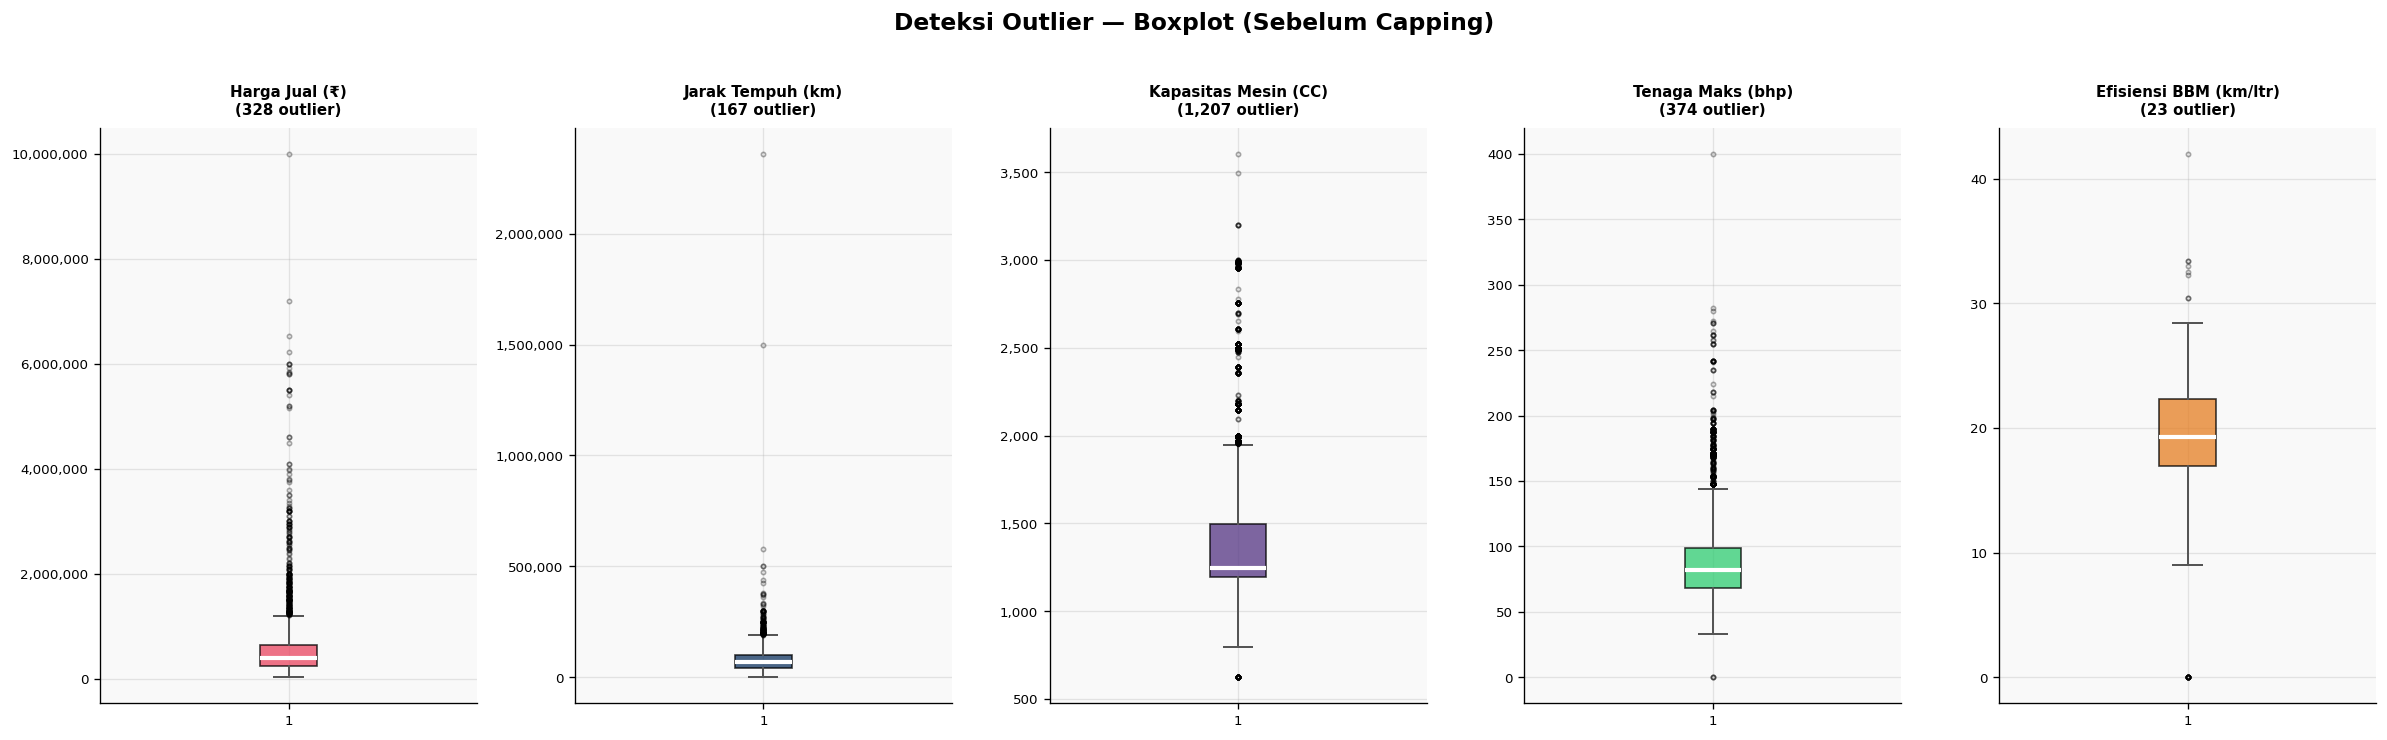

In [88]:
# ============================================================
#  BOXPLOT — VISUALISASI OUTLIER SEBELUM CAPPING
# ============================================================
outlier_cols  = ['selling_price', 'km_driven', 'engine', 'max_power', 'mileage(km/ltr/kg)']
outlier_labels = ['Harga Jual (₹)', 'Jarak Tempuh (km)', 'Kapasitas Mesin (CC)',
                  'Tenaga Maks (bhp)', 'Efisiensi BBM (km/ltr)']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, (col, lbl) in enumerate(zip(outlier_cols, outlier_labels)):
    bp = axes[i].boxplot(
        df[col].dropna(), patch_artist=True, vert=True,
        boxprops     = dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.75),
        medianprops  = dict(color='white', linewidth=2.5),
        whiskerprops = dict(color='#555', linewidth=1.2),
        capprops     = dict(color='#555', linewidth=1.2),
        flierprops   = dict(marker='o', color='#e74c3c', alpha=0.35, markersize=2.5)
    )
    n_outliers = ((df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25))) |
                  (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)))).sum()
    axes[i].set_title(
        f'{lbl}\n({n_outliers:,} outlier)',
        fontsize=9, fontweight='bold', pad=8
    )
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[i].tick_params(labelsize=8)

fig.suptitle('Deteksi Outlier — Boxplot (Sebelum Capping)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Boxplot adalah alat visualisasi yang ideal untuk mendeteksi outlier:

- **Kotak (box)**: Rentang antara Q1 (kuartil bawah) dan Q3 (kuartil atas) — disebut IQR.
- **Garis tengah**: Nilai median (Q2).
- **Whisker**: Batas hingga 1.5×IQR dari kotak.
- **Titik merah**: Nilai di luar whisker — ini adalah **outlier**.

**Interpretasi per kolom:**
- `selling_price`: Banyak titik outlier di atas — mobil premium/mewah dengan harga sangat tinggi.
- `km_driven`: Ada outlier ekstrem (>600.000 km) yang tidak wajar untuk pemakaian normal.
- `engine`, `max_power`: Outlier lebih sedikit, sebagian besar adalah supercar/luxury.
- `mileage`: Relatif bersih, hanya outlier rendah (efisiensi sangat buruk).


In [89]:
def iqr_capping(dataframe, column):
    """IQR Capping: membatasi nilai ekstrem pada batas Q1-1.5*IQR dan Q3+1.5*IQR."""
    Q1  = dataframe[column].quantile(0.25)
    Q3  = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    n_below = (dataframe[column] < lower).sum()
    n_above = (dataframe[column] > upper).sum()
    dataframe[column] = dataframe[column].clip(lower=lower, upper=upper)
    return n_below, n_above, lower, upper

print('🔧 IQR Capping — Hasil per Kolom:')
print()
print(f"{'Kolom':<26} {'Batas Bawah':>14} {'Batas Atas':>14} {'Di Bawah':>9} {'Di Atas':>9} {'Total Cap':>10}")
print('─' * 88)

total_capped = 0
for col in outlier_cols:
    n_lo, n_hi, lo, hi = iqr_capping(df, col)
    total_capped += n_lo + n_hi
    print(f'  {col:<24} {lo:>14,.1f} {hi:>14,.1f} {n_lo:>9,} {n_hi:>9,} {n_lo+n_hi:>10,}')

print('─' * 88)
print(f'  {"TOTAL":<24} {"":>14} {"":>14} {"":>9} {"":>9} {total_capped:>10,}')
print()
print(f' Winsorization selesai. Shape dataset: {df.shape}')


🔧 IQR Capping — Hasil per Kolom:

Kolom                         Batas Bawah     Batas Atas  Di Bawah   Di Atas  Total Cap
────────────────────────────────────────────────────────────────────────────────────────
  selling_price                -325,250.0    1,208,750.0         0       328        328
  km_driven                     -50,000.0      190,000.0         0       167        167
  engine                            745.5        1,949.5        25     1,182      1,207
  max_power                          21.5          145.5         3       371        374
  mileage(km/ltr/kg)                  8.9           30.4        15         8         23
────────────────────────────────────────────────────────────────────────────────────────
  TOTAL                                                                           2,099

 Winsorization selesai. Shape dataset: (6926, 12)


**📝 Penjelasan Output:**

Tabel hasil IQR capping menunjukkan untuk setiap kolom:
- **Batas Bawah / Atas**: Nilai threshold yang dihitung dari IQR.
- **Di Bawah / Di Atas**: Jumlah nilai yang berada di bawah/atas batas.
- **Total Cap**: Jumlah nilai yang dimodifikasi (bukan dihapus).

**Keunggulan IQR Capping vs. penghapusan baris:**
1.  **Tidak kehilangan data** — jumlah baris tetap sama.
2.  **Distribusi lebih normal** — ekor panjang dipotong.
3.  **Informasi tetap ada** — kita tahu kendaraan itu ada, nilainya saja yang dinormalkan.

>  Konsekuensi: Nilai maksimum `selling_price` setelah capping bukan lagi harga asli
> mobil termewah, melainkan nilai batas atas IQR. Ini bisa menjadi catatan dalam laporan.


---
## 8️⃣ Feature Engineering

Feature engineering adalah proses membuat **fitur baru** yang lebih informatif dari fitur
yang sudah ada. Tujuannya adalah menyediakan informasi yang lebih bermakna bagi model
machine learning, yang kadang tidak bisa ditangkap dari fitur mentah.

### Fitur Baru yang Dibuat

| Fitur Baru | Dibuat dari | Alasan |
|:---|:---|:---|
| `car_age` | `year` | Usia lebih relevan untuk model daripada tahun absolut |
| `brand` | `name` | Merek adalah prediktor harga yang kuat |
| `km_per_year` | `km_driven / car_age` | Mengukur intensitas pemakaian |
| `price_per_cc` | `selling_price / engine` | Indikator efisiensi harga per kapasitas mesin |
| `is_recent` | `car_age ≤ 5` | Flag biner kendaraan "relatif baru" |


In [90]:
CURRENT_YEAR = 2025

# ── 1. Usia kendaraan ────────────────────────────────────────
df['car_age'] = CURRENT_YEAR - df['year']
print(f' [1] car_age      → rentang: {df["car_age"].min()}–{df["car_age"].max()} tahun')

# ── 2. Ekstraksi merek (kata pertama dari nama) ──────────────
df['brand'] = df['name'].str.split().str[0].str.strip()
print(f' [2] brand        → {df["brand"].nunique()} merek unik ditemukan')

# ── 3. Km per tahun (intensitas pemakaian) ───────────────────
df['km_per_year'] = (df['km_driven'] / df['car_age'].replace(0, 1)).round(1)
print(f' [3] km_per_year  → rata-rata: {df["km_per_year"].mean():,.0f} km/tahun')

# ── 4. Harga per CC (efisiensi harga vs. kapasitas mesin) ────
df['price_per_cc'] = (df['selling_price'] / df['engine']).round(2)
print(f' [4] price_per_cc → rata-rata: {df["price_per_cc"].mean():,.0f} ₹/CC')

# ── 5. Flag kendaraan baru (≤5 tahun) ───────────────────────
df['is_recent'] = (df['car_age'] <= 5).astype(int)
pct_recent = df['is_recent'].mean() * 100
print(f' [5] is_recent    → {df["is_recent"].sum():,} kendaraan ({pct_recent:.1f}%) berusia ≤5 tahun')

print()
print(f'📐 Shape setelah feature engineering: {df.shape[0]:,} × {df.shape[1]}')


 [1] car_age      → rentang: 5–42 tahun
 [2] brand        → 32 merek unik ditemukan
 [3] km_per_year  → rata-rata: 6,221 km/tahun
 [4] price_per_cc → rata-rata: 339 ₹/CC
 [5] is_recent    → 63 kendaraan (0.9%) berusia ≤5 tahun

📐 Shape setelah feature engineering: 6,926 × 17


**📝 Penjelasan Output:**

Kelima fitur baru berhasil dibuat dengan karakteristik berikut:

- **`car_age`**: Lebih langsung merepresentasikan "nilai" kendaraan dibanding `year`.
  Model lebih mudah belajar bahwa kendaraan 3 tahun > 10 tahun dalam hal harga.

- **`brand`**: Diekstraksi dari nama lengkap menggunakan `.str.split().str[0]`.
  Merek seperti Maruti, Hyundai, Honda memiliki persepsi nilai yang berbeda di pasar.

- **`km_per_year`**: Memberikan konteks pemakaian. Kendaraan yang telah ditempuh
  10.000 km selama 10 tahun (1.000 km/tahun) jauh berbeda kondisinya dibanding
  yang menempuh 10.000 km dalam 1 tahun.

- **`price_per_cc`**: Rasio harga terhadap kapasitas mesin berguna untuk membandingkan
  "value for money" antar kendaraan dengan ukuran mesin berbeda.

- **`is_recent`**: Fitur biner yang bisa membantu model menangkap perbedaan
  mencolok antara kendaraan baru dan lama.


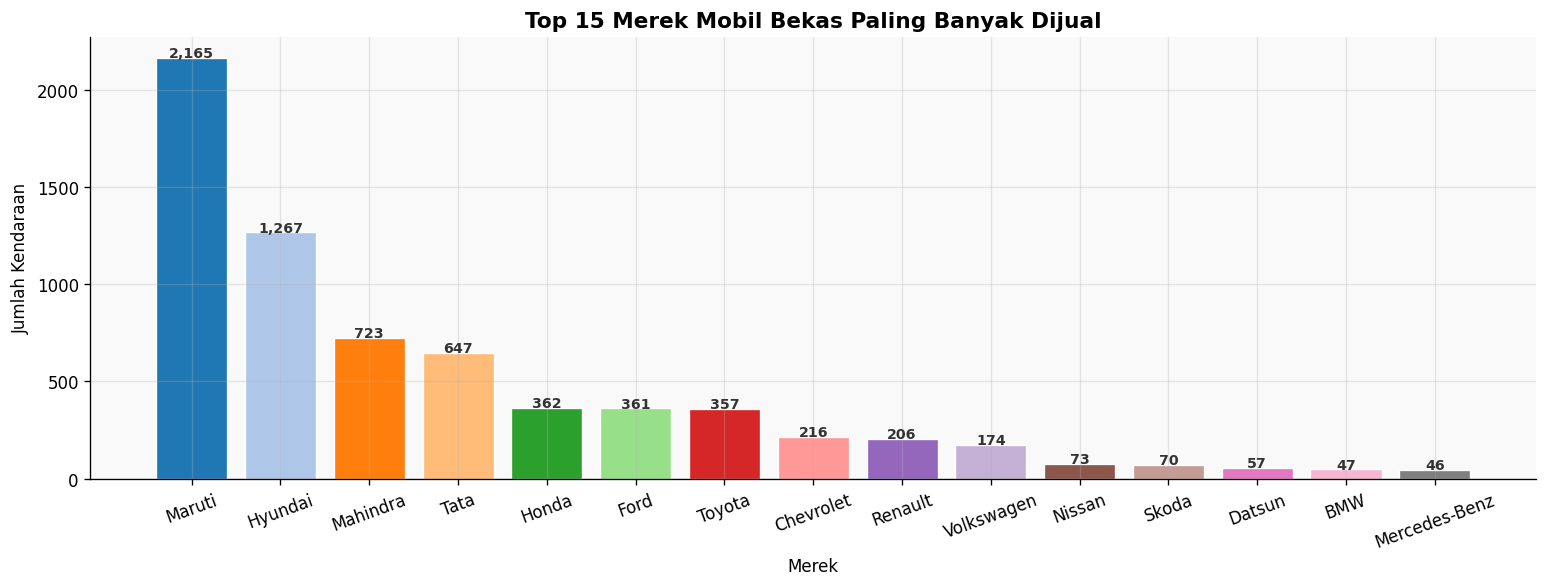

In [91]:
top_brands = df['brand'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.tab20.colors[:15]
bars = ax.bar(top_brands.index, top_brands.values, color=colors, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
        f'{int(bar.get_height()):,}', ha='center', fontsize=8.5, fontweight='bold', color='#333'
    )

ax.set_title('Top 15 Merek Mobil Bekas Paling Banyak Dijual', fontsize=13, fontweight='bold')
ax.set_xlabel('Merek')
ax.set_ylabel('Jumlah Kendaraan')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Grafik batang menampilkan 15 merek dengan inventori terbesar di dataset:

- **Maruti** (Maruti Suzuki) mendominasi jauh di atas — mencerminkan posisinya sebagai
  merek mobil terlaris di India selama puluhan tahun.
- **Hyundai** berada di posisi kedua sebagai merek Korea yang populer.
- Merek Jepang (Toyota, Honda) dan India-lokal (Mahindra, Tata) juga masuk top 15.
- Distribusi yang tidak merata ini penting diperhatikan saat encoding —
  merek minoritas mungkin memiliki sedikit sampel untuk dipelajari model.


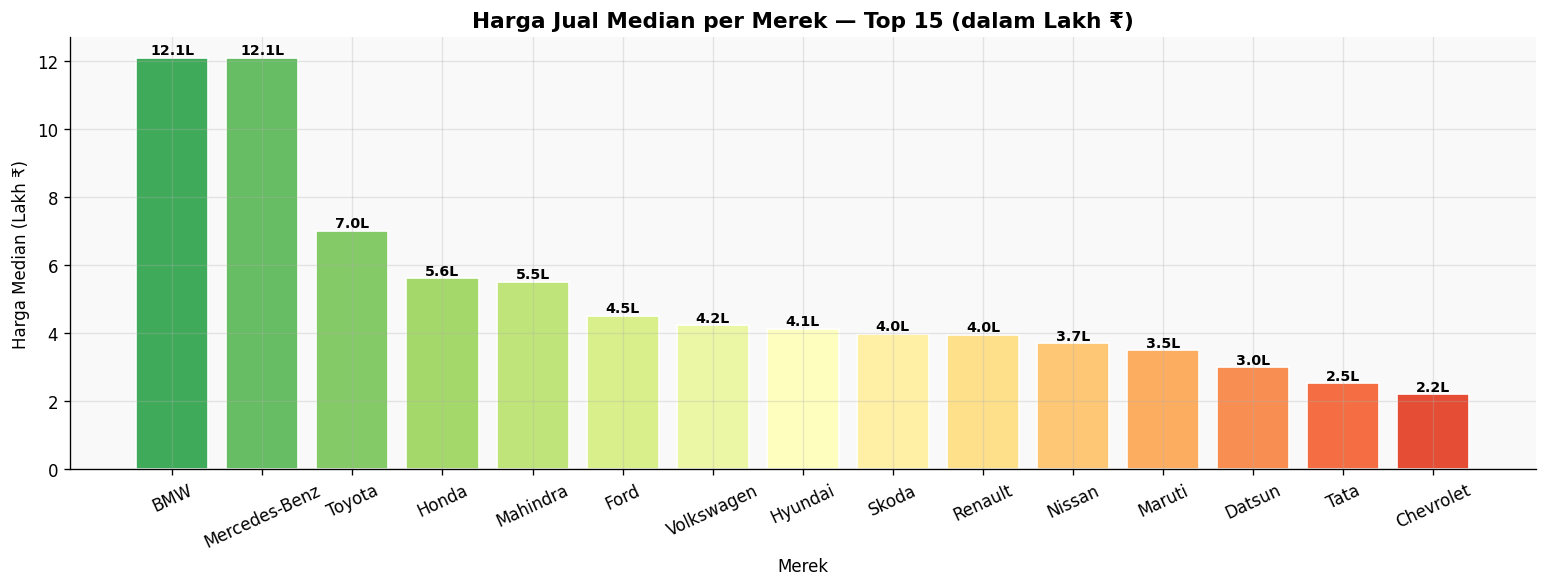

In [92]:
brand_price = (
    df[df['brand'].isin(top_brands.index)]
    .groupby('brand')['selling_price']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(brand_price)))[::-1]
bars = ax.bar(brand_price.index, brand_price.values / 1e5, color=bar_colors, edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
        f'{bar.get_height():.1f}L', ha='center', fontsize=8.5, fontweight='bold'
    )

ax.set_title('Harga Jual Median per Merek — Top 15 (dalam Lakh ₹)', fontsize=13, fontweight='bold')
ax.set_xlabel('Merek')
ax.set_ylabel('Harga Median (Lakh ₹)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Grafik ini menunjukkan harga median kendaraan bekas untuk setiap merek (dalam satuan Lakh ₹ = 100.000 ₹):

- Merek premium seperti **Mercedes**, **BMW**, atau **Audi** (jika ada di top 15) akan
  menunjukkan median harga yang jauh lebih tinggi.
- **Maruti** yang paling banyak dijual cenderung memiliki median harga rendah karena
  fokus pada segmen ekonomi.
- Grafik ini memperkuat keputusan untuk menjadikan `brand` sebagai fitur —
  ada variasi harga yang jelas antar merek.
- Warna gradasi (hijau → merah) mempermudah identifikasi merek premium vs. ekonomi.


---
## 9️⃣ Encoding Variabel Kategorical

Model machine learning hanya bisa bekerja dengan **data numerik**.
Variabel kategorical perlu diubah ke representasi angka. Strategi encoding dipilih
berdasarkan sifat variabel:

| Variabel | Jenis | Strategi | Alasan |
|:---|:---:|:---|:---|
| `transmission` | Binary | Label Encoding (0/1) | Hanya 2 nilai |
| `owner` | Ordinal | Ordinal Mapping manual | Ada urutan makna (1st < 2nd < ...) |
| `fuel` | Nominal | Label Encoding | Tidak ada urutan alami |
| `seller_type` | Nominal | Label Encoding | Tidak ada urutan alami |
| `brand` | Nominal | Label Encoding | Banyak kategori, referensi analisis |


In [93]:
# ── 1. Transmisi (Binary) ────────────────────────────────────
df['transmission_enc'] = (df['transmission'] == 'Automatic').astype(int)
print(' [1] transmission_enc : Manual=0 | Automatic=1')
print(f'       Distribusi: {df["transmission_enc"].value_counts().to_dict()}')
print()

# ── 2. Owner (Ordinal) ───────────────────────────────────────
owner_map = {
    'Test Drive Car'      : 0,
    'First Owner'         : 1,
    'Second Owner'        : 2,
    'Third Owner'         : 3,
    'Fourth & Above Owner': 4,
}
df['owner_enc'] = df['owner'].map(owner_map)
print('[2] owner_enc        : Ordinal mapping')
print(f'       Mapping: {owner_map}')
unmapped = df['owner_enc'].isnull().sum()
if unmapped > 0:
    print(f'         {unmapped} nilai tidak terpetakan (NaN)')
print()

# ── 3. Fuel (Nominal) ────────────────────────────────────────
le_fuel = LabelEncoder()
df['fuel_enc'] = le_fuel.fit_transform(df['fuel'])
fuel_map = dict(zip(le_fuel.classes_, le_fuel.transform(le_fuel.classes_)))
print(f' [3] fuel_enc         : Label Encoding → {fuel_map}')
print()

# ── 4. Seller Type (Nominal) ─────────────────────────────────
le_seller = LabelEncoder()
df['seller_type_enc'] = le_seller.fit_transform(df['seller_type'])
seller_map = dict(zip(le_seller.classes_, le_seller.transform(le_seller.classes_)))
print(f' [4] seller_type_enc  : Label Encoding → {seller_map}')
print()

# ── 5. Brand (Nominal) ───────────────────────────────────────
le_brand = LabelEncoder()
df['brand_enc'] = le_brand.fit_transform(df['brand'])
print(f' [5] brand_enc        : Label Encoding → {df["brand"].nunique()} merek (0–{df["brand"].nunique()-1})')


 [1] transmission_enc : Manual=0 | Automatic=1
       Distribusi: {0: 6342, 1: 584}

[2] owner_enc        : Ordinal mapping
       Mapping: {'Test Drive Car': 0, 'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Fourth & Above Owner': 4}

 [3] fuel_enc         : Label Encoding → {'CNG': 0, 'Diesel': 1, 'LPG': 2, 'Petrol': 3}

 [4] seller_type_enc  : Label Encoding → {'Dealer': 0, 'Individual': 1, 'Trustmark Dealer': 2}

 [5] brand_enc        : Label Encoding → 32 merek (0–31)


**📝 Penjelasan Output:**

Setiap baris konfirmasi menunjukkan kolom baru yang dibuat dan skema encoding yang diterapkan:

1. **`transmission_enc`**: Binary 0/1 — paling sederhana dan tidak menambah dimensi.

2. **`owner_enc`**: Ordinal mapping manual dipilih karena urutan kepemilikan memiliki
   makna yang jelas: First Owner lebih "baik" dari Second Owner. Menggunakan angka 0–4
   mempertahankan hubungan ordinal ini.
   `Test Drive Car` diberi nilai 0 karena status khusus (bukan benar-benar "dimiliki").

3. **`fuel_enc`**: Label Encoding digunakan karena kategori fuel tidak memiliki urutan
   natural. (Catatan: One-Hot Encoding bisa jadi alternatif yang lebih baik untuk
   model berbasis pohon/linear, tetapi Label Encoding cukup sebagai baseline.)

4. **`seller_type_enc`** & **`brand_enc`**: Sama, Label Encoding untuk nominal.

>  **Catatan metodologis:** Label Encoding untuk variabel nominal (fuel, seller_type, brand)
> secara implisit memberikan urutan palsu (Dealer=0 < Individual=1 < Trustmark=2).
> Untuk model linear atau neural net, **One-Hot Encoding** lebih tepat. Namun untuk
> tree-based models (Random Forest, XGBoost), Label Encoding sudah cukup.


---
## 🔟 Normalisasi / Scaling Fitur Numerik

Fitur numerik memiliki **skala yang sangat berbeda**: `km_driven` bisa mencapai ratusan ribu
sementara `seats` hanya 2–9. Perbedaan skala ini dapat menyebabkan model dengan basis jarak
(KNN, SVM) atau gradient descent (Neural Network) memberikan bobot berlebih pada fitur
berskala besar.

**Min-Max Scaling** mentransformasi setiap nilai ke rentang **[0, 1]**:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$


In [94]:
scale_cols = [
    'year', 'km_driven', 'mileage(km/ltr/kg)',
    'engine', 'max_power', 'seats',
    'car_age', 'km_per_year', 'price_per_cc'
]

scaler      = MinMaxScaler()
scaled_arr  = scaler.fit_transform(df[scale_cols])
scaled_df   = pd.DataFrame(
    scaled_arr,
    columns=[f'{c}_scaled' for c in scale_cols],
    index=df.index
)
df = pd.concat([df, scaled_df], axis=1)

print(' Min-Max Scaling selesai:')
print()
print(f"{'Kolom Asli':<28} {'Min Asli':>12} {'Max Asli':>14} {'Min Scaled':>11} {'Max Scaled':>11}")
print('─' * 80)
for col in scale_cols:
    print(
        f"  {col:<26} "
        f"{df[col].min():>12,.1f} "
        f"{df[col].max():>14,.1f} "
        f"{df[col+'_scaled'].min():>11.4f} "
        f"{df[col+'_scaled'].max():>11.4f}"
    )


 Min-Max Scaling selesai:

Kolom Asli                       Min Asli       Max Asli  Min Scaled  Max Scaled
────────────────────────────────────────────────────────────────────────────────
  year                            1,983.0        2,020.0      0.0000      1.0000
  km_driven                           1.0      190,000.0      0.0000      1.0000
  mileage(km/ltr/kg)                  8.9           30.4      0.0000      1.0000
  engine                            745.5        1,949.5      0.0000      1.0000
  max_power                          21.5          145.5      0.0000      1.0000
  seats                               2.0           14.0      0.0000      1.0000
  car_age                             5.0           42.0      0.0000      1.0000
  km_per_year                         0.1       24,000.0      0.0000      1.0000
  price_per_cc                       24.0        1,152.3      0.0000      1.0000


**📝 Penjelasan Output:**

Tabel konfirmasi scaling menampilkan nilai min/max **sebelum** dan **sesudah** normalisasi:

- Setiap kolom yang di-scale kini memiliki nilai **minimum = 0.0000** dan **maksimum = 1.0000**.
- Kolom asli **tetap dipertahankan** di dataset — scaling hanya menambah kolom baru
  dengan suffix `_scaled`. Ini memungkinkan kita membandingkan nilai asli kapan pun dibutuhkan.
- Contoh: `km_driven` yang semula 1–671.000 km kini menjadi 0–1.

**Kapan Min-Max Scaling sesuai?**
-  Distribusi data sudah diketahui dan outlier sudah ditangani (kita sudah IQR capping).
-  Model yang akan digunakan sensitif terhadap skala (KNN, SVM, Neural Network).
-  Untuk tree-based models (Decision Tree, Random Forest), scaling tidak wajib tetapi tidak merugikan.


---
## 1️⃣1️⃣ Analisis Korelasi

Analisis korelasi membantu kita memahami **seberapa kuat** dan **dalam arah apa**
setiap fitur berhubungan dengan variabel target (`selling_price`).
Kita menggunakan **Pearson Correlation** yang mengukur hubungan linear antara dua variabel.

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

Nilai $r$ berkisar dari **-1** (korelasi negatif sempurna) hingga **+1** (korelasi positif sempurna).


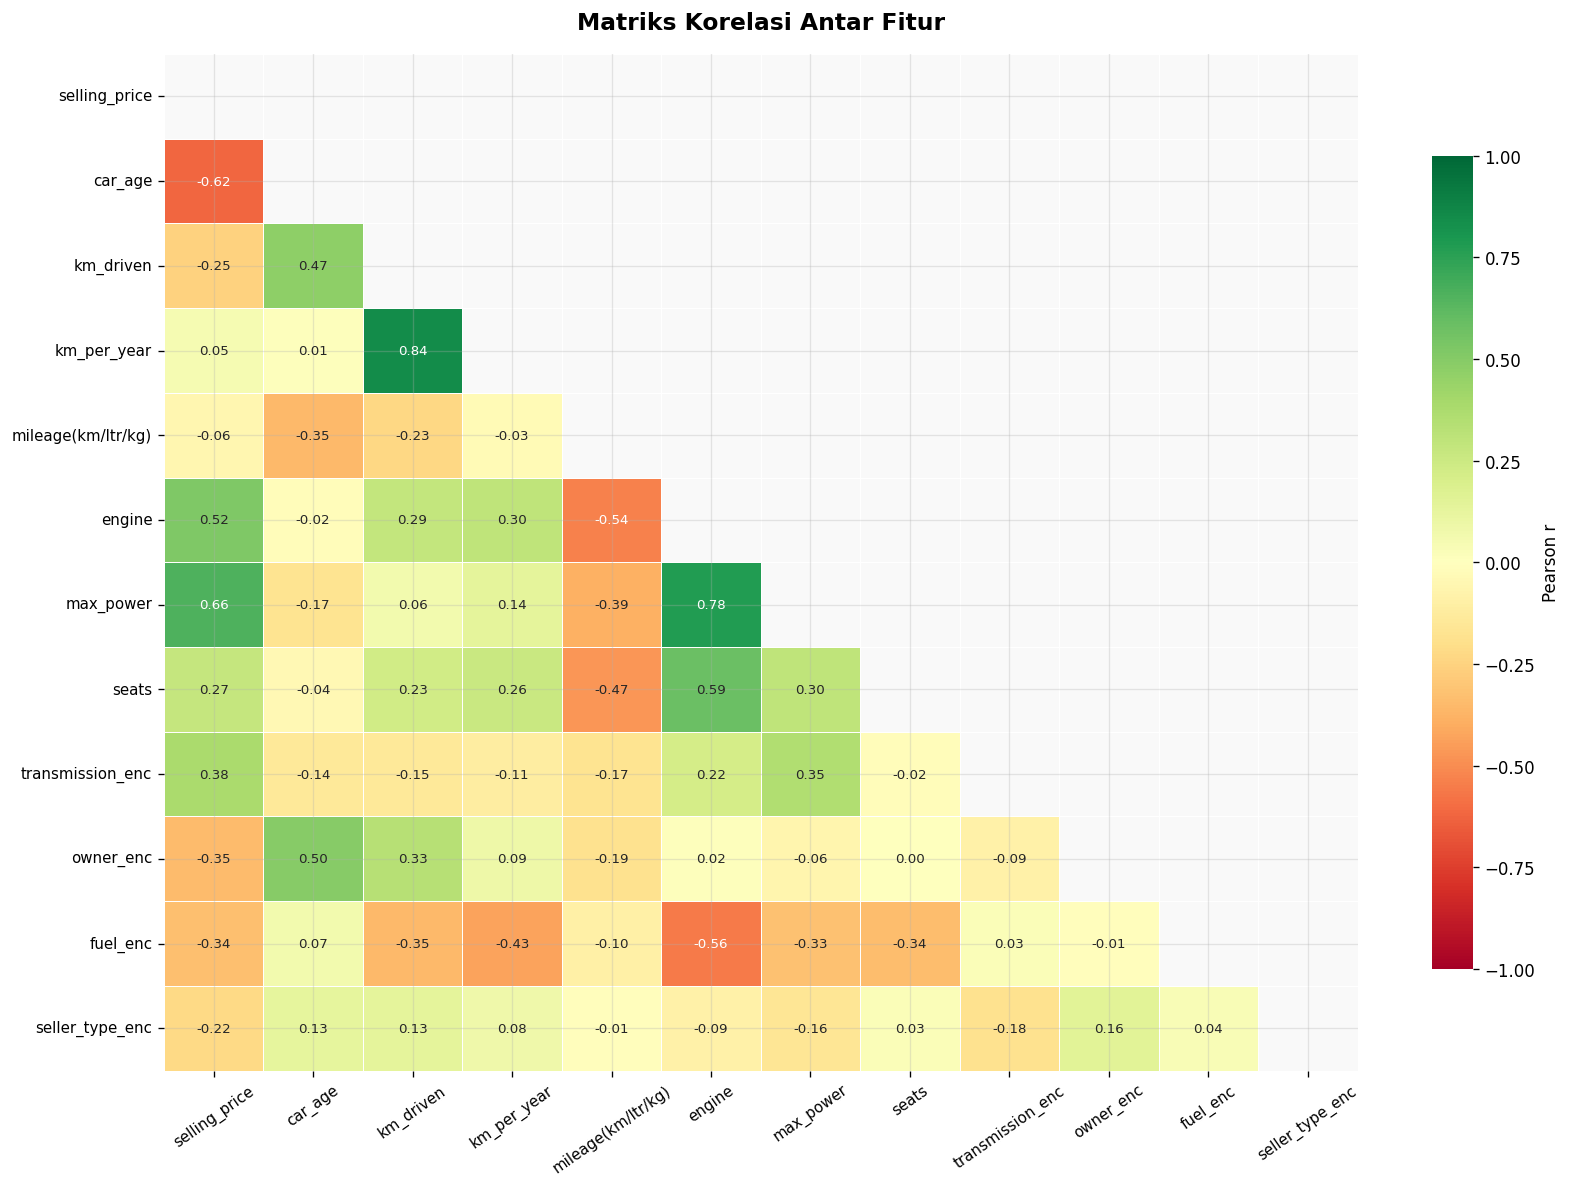

In [95]:
corr_cols = [
    'selling_price', 'car_age', 'km_driven', 'km_per_year',
    'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats',
    'transmission_enc', 'owner_enc', 'fuel_enc', 'seller_type_enc'
]

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # sembunyikan segitiga atas

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax, vmin=-1, vmax=1,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
ax.set_title('Matriks Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Heatmap segitiga bawah menampilkan nilai korelasi Pearson antara semua pasangan fitur:

- **Warna hijau (mendekati +1)**: Korelasi positif — kedua variabel naik bersama.
- **Warna merah (mendekati -1)**: Korelasi negatif — satu naik, lainnya turun.
- **Warna kuning (mendekati 0)**: Hampir tidak ada hubungan linear.

**Korelasi kuat terhadap `selling_price` (baris/kolom pertama):**
- `max_power` (+) — Mesin bertenaga lebih mahal.
- `engine` (+) — Kapasitas mesin besar cenderung mahal.
- `car_age` (−) — Semakin tua, semakin murah.
- `transmission_enc` (+) — Automatic lebih mahal dari Manual.

**Multikolinearitas yang perlu diperhatikan:**
- `engine` dan `max_power` berkorelasi sangat tinggi satu sama lain (wajar — mesin besar biasanya lebih bertenaga). Ini bisa menjadi masalah untuk model linear (ridge regression lebih disarankan).


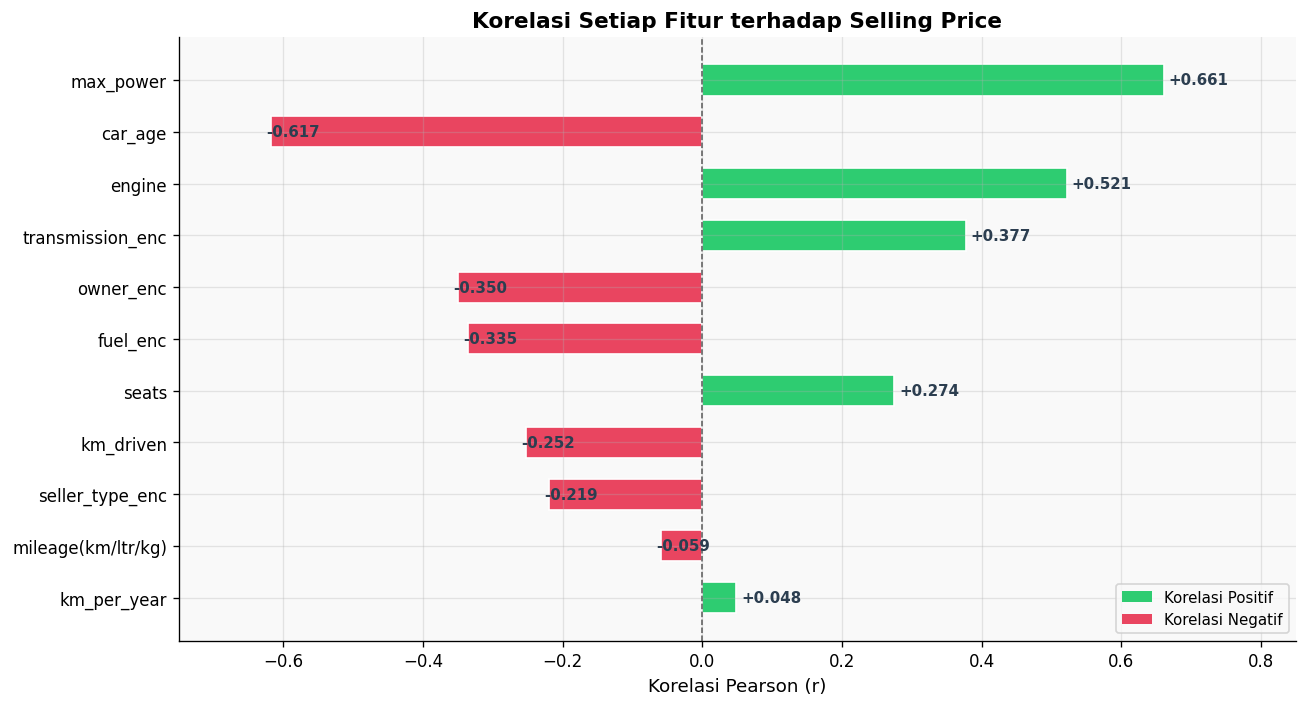

In [96]:
target_corr = (
    corr_matrix['selling_price']
    .drop('selling_price')
    .sort_values(key=abs, ascending=True)
)

colors = ['#2ecc71' if v > 0 else '#e94560' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='#555', linewidth=0.9, linestyle='--')

for bar, val in zip(bars, target_corr.values):
    ax.text(
        val + 0.007 * np.sign(val), bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}', va='center', fontsize=9, fontweight='bold',
        color='#2c3e50'
    )

ax.set_xlabel('Korelasi Pearson (r)', fontsize=11)
ax.set_title('Korelasi Setiap Fitur terhadap Selling Price', fontsize=13, fontweight='bold')
ax.set_xlim(-0.75, 0.85)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Korelasi Positif'),
    Patch(facecolor='#e94560', label='Korelasi Negatif')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


**📝 Penjelasan Output:**

Grafik horizontal bar yang diurutkan dari korelasi terkecil ke terbesar memberikan
ranking fitur berdasarkan kekuatan hubungannya dengan `selling_price`:

| Fitur | Korelasi | Interpretasi |
|:---|:---:|:---|
| `max_power` | ++ positif | Fitur terkuat — mesin bertenaga = harga tinggi |
| `engine` | + positif | Kapasitas mesin besar = lebih mahal |
| `transmission_enc` | + positif | Automatic lebih mahal dari Manual |
| `car_age` | −− negatif | Kendaraan tua = harga lebih rendah |
| `owner_enc` | − negatif | Banyak berpindah tangan = harga turun |
| `km_driven` | − negatif | Lebih banyak km = nilai lebih rendah |
| `km_per_year` | ~ lemah | Intensitas pemakaian, korelasi moderat |

Fitur dengan korelasi mendekati 0 (seperti `fuel_enc`, `seller_type_enc`) memiliki
hubungan linear yang lemah, namun bisa tetap berguna untuk model non-linear.


---
## 1️⃣2️⃣ Finalisasi & Ekspor Dataset

Tahap terakhir: menyusun **dataset final** yang hanya berisi fitur-fitur terpilih
dan variabel target, kemudian menyimpannya sebagai file CSV siap modeling.

Kita akan membuat **2 file output**:
1. `cardekho_preprocessed_full.csv` — Dataset lengkap dengan semua kolom (asli + baru).
2. `cardekho_ready_for_modeling.csv` — Hanya fitur terpilih + target (siap untuk train-test split).


In [97]:
feature_cols = [
    # Fitur numerik ter-scaling
    'year_scaled', 'km_driven_scaled', 'mileage(km/ltr/kg)_scaled',
    'engine_scaled', 'max_power_scaled', 'seats_scaled',
    'car_age_scaled', 'km_per_year_scaled', 'price_per_cc_scaled',
    # Fitur encoded
    'transmission_enc', 'owner_enc', 'fuel_enc',
    'seller_type_enc', 'is_recent', 'brand_enc'
]

df_model = df[feature_cols + ['selling_price']].copy()
missing_final = df_model.isnull().sum().sum()
print(f'  Shape              : {df_model.shape[0]:,} baris × {df_model.shape[1]} kolom')
print(f'  Fitur input (X)    : {len(feature_cols)} kolom')
print(f'  Target (y)         : selling_price')
print(f'  Missing values     : {missing_final} ')
print()
print('📋 Preview 5 baris pertama:')
display(df_model.head())


  Shape              : 6,926 baris × 16 kolom
  Fitur input (X)    : 15 kolom
  Target (y)         : selling_price
  Missing values     : 0 

📋 Preview 5 baris pertama:


,year_scaled,km_driven_scaled,mileage(km/ltr/kg)_scaled,engine_scaled,max_power_scaled,seats_scaled,car_age_scaled,km_per_year_scaled,price_per_cc_scaled,transmission_enc,owner_enc,fuel_enc,seller_type_enc,is_recent,brand_enc,selling_price
0,0.84,0.77,0.68,0.42,0.42,0.25,0.16,0.55,0.30,0,1,1,1,0,20,450000
1,0.84,0.63,0.57,0.62,0.66,0.25,0.16,0.45,0.20,0,2,1,1,0,27,370000
2,0.62,0.74,0.41,0.62,0.46,0.25,0.38,0.31,0.07,0,3,3,1,0,10,158000
3,0.73,0.67,0.66,0.54,0.55,0.25,0.27,0.35,0.12,0,1,1,1,0,11,225000
4,0.65,0.63,0.34,0.46,0.54,0.25,0.35,0.28,0.07,0,1,3,1,0,20,130000


**📝 Penjelasan Output:**

Ringkasan dataset final mengkonfirmasi:
- **Jumlah fitur input**: 15 kolom (9 fitur numerik ter-scaling + 6 fitur encoded).
- **Target**: `selling_price` dalam satuan Rupee India (belum di-transform — untuk regresi).
- **Missing values = 0**: Dataset bersih dan siap digunakan.
- **Shape**: Jumlah baris sedikit berkurang dari 8.128 akibat penghapusan duplikat.

>  Dataset ini bisa langsung di-split menggunakan `train_test_split` dari sklearn
> dengan cara: `X = df_model.drop('selling_price', axis=1)` dan `y = df_model['selling_price']`.


In [98]:
# ── Preview statistik ringkas fitur final ───────────────────
print(' Statistik Ringkas Dataset Final:')
display(df_model.describe().round(3).T.style
        .background_gradient(cmap='Greens', subset=['mean'])
        .format('{:.3f}'))


 Statistik Ringkas Dataset Final:


,count,mean,std,min,25%,50%,75%,max
year_scaled,6926.000,0.822,0.110,0.000,0.757,0.838,0.919,1.000
km_driven_scaled,6926.000,0.380,0.229,0.000,0.211,0.368,0.526,1.000
mileage(km/ltr/kg)_scaled,6926.000,0.493,0.182,0.000,0.375,0.484,0.625,1.000
engine_scaled,6926.000,0.507,0.283,0.000,0.375,0.417,0.625,1.000
max_power_scaled,6926.000,0.519,0.210,0.000,0.375,0.487,0.625,1.000
seats_scaled,6926.000,0.285,0.081,0.000,0.250,0.250,0.250,1.000
car_age_scaled,6926.000,0.178,0.110,0.000,0.081,0.162,0.243,1.000
km_per_year_scaled,6926.000,0.259,0.144,0.000,0.155,0.238,0.333,1.000
price_per_cc_scaled,6926.000,0.279,0.156,0.000,0.153,0.263,0.389,1.000
transmission_enc,6926.000,0.084,0.278,0.000,0.000,0.000,0.000,1.000


**📝 Penjelasan Output:**

Statistik deskriptif dataset final mengkonfirmasi keberhasilan preprocessing:

- Kolom `*_scaled` memiliki nilai antara **0 dan 1** persis — scaling berhasil.
- Kolom encoded (`*_enc`) menunjukkan rentang nilai diskret sesuai mapping.
- `selling_price` (target) masih dalam skala asli ₹ — umumnya tidak di-scale
  untuk regresi, namun bisa dipertimbangkan jika menggunakan neural network.


In [99]:
df.to_csv('cardekho_preprocessed_full.csv', index=False)
df_model.to_csv('cardekho_ready_for_modeling.csv', index=False)

print(' File berhasil disimpan:')
print()
print(f'   cardekho_preprocessed_full.csv')
print(f'     → {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'     → Semua kolom asli + kolom baru + kolom scaled')
print()
print(f'   cardekho_ready_for_modeling.csv')
print(f'     → {df_model.shape[0]:,} baris × {df_model.shape[1]} kolom')
print(f'     → Fitur terseleksi (15 kolom) + target selling_price')
print(f'     → Siap untuk train_test_split & modeling')


 File berhasil disimpan:

   cardekho_preprocessed_full.csv
     → 6,926 baris × 31 kolom
     → Semua kolom asli + kolom baru + kolom scaled

   cardekho_ready_for_modeling.csv
     → 6,926 baris × 16 kolom
     → Fitur terseleksi (15 kolom) + target selling_price
     → Siap untuk train_test_split & modeling


---
## 📋 Ringkasan Lengkap Pipeline Preprocessing

<div style="background: linear-gradient(135deg, #0d0d1a, #0f2f5a); padding: 30px 36px;
     border-radius: 14px; color: white; font-family: 'Segoe UI', sans-serif;">

| # | Tahap | Metode | Hasil |
|:---:|:---|:---|:---|
| 1 | **Import & Konfigurasi** | — | Semua library siap, tema visual konsisten |
| 2 | **Load Dataset** | `pd.read_csv()` | 8.128 baris × 12 kolom dimuat |
| 3 | **Konversi Tipe Data** | `pd.to_numeric(..., errors='coerce')` | 4 kolom object → float64 |
| 4 | **EDA** | Histogram, Bar Chart, Describe | Distribusi skewed & imbalanced class teridentifikasi |
| 5 | **Missing Values** | Median Imputation | ~221 nilai NaN diisi di 4 kolom |
| 6 | **Duplikat** | `drop_duplicates()` | Baris ganda dihapus, shape bersih |
| 7 | **Outlier** | IQR Capping (Winsorization) | Nilai ekstrem dibatasi tanpa membuang data |
| 8 | **Feature Engineering** | Ekstraksi & Transformasi | +5 fitur baru (car_age, brand, km_per_year, …) |
| 9 | **Encoding** | Label + Ordinal Encoding | 5 kolom kategorical → numerik |
| 10 | **Scaling** | Min-Max Scaler [0,1] | 9 kolom numerik dinormalisasi |
| 11 | **Korelasi** | Pearson Heatmap | `max_power` & `engine` paling berkorelasi dengan target |
| 12 | **Ekspor** | `to_csv()` | 2 file output: full dataset + modeling-ready |

**Dataset Final:** `{n_rows} baris × 16 kolom` (15 fitur + 1 target)

</div>
